## Importando as Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com Sucesso!!")

Bibliotecas importadas com Sucesso!!


## Visão Geral dos Dados

In [4]:
dados = pd.read_csv("../data/dados_spam.csv", index_col=0)
dados.head()

,categoria,texto
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print(f"Total de Linhas -> {len(dados)}")
print("\n\n=== INFORMAÇÕES DO DATASET ===")
print(dados.info())

Total de Linhas -> 5574


=== INFORMAÇÕES DO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   categoria  5574 non-null   str  
 1   texto      5574 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None


In [6]:
print("=== VERIFICANDO DADOS NULOS ===")
print(dados.isna().sum())

=== VERIFICANDO DADOS NULOS ===
categoria    0
texto        0
dtype: int64


## Verificando a Distribuição das Classes

In [9]:
print(f"Total de Classes -> {dados["categoria"].nunique()}")

Total de Classes -> 2


In [11]:
classes = dados["categoria"].value_counts()
classes

categoria
ham     4827
spam     747
Name: count, dtype: int64

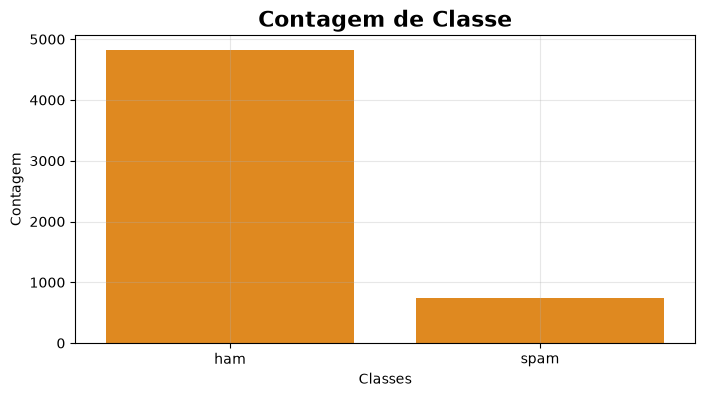

In [13]:
plt.figure(figsize=(8,4))

sns.countplot(x=dados["categoria"], color="darkorange")
plt.title("Contagem de Classe", fontsize=16, fontweight="bold")
plt.xlabel("Classes")
plt.ylabel("Contagem")
plt.grid(alpha=0.3)
plt.show()

## Entendendo o Vocabulário

In [14]:
from collections import Counter

In [15]:
all_words = " ".join(dados["texto"]).lower().split()

word_freq = Counter(all_words)

### Pegando TOP 10 palavras do Vocabulário (Sem StopWords)

In [17]:
top_10_words = word_freq.most_common(10)

df_top_words = pd.DataFrame(
    top_10_words,
    columns=["word", "frequency"]
)

df_top_words

,word,frequency
0,to,2237
1,i,2217
2,you,1921
3,a,1433
4,the,1328
5,u,998
6,and,968
7,is,869
8,in,859
9,my,755


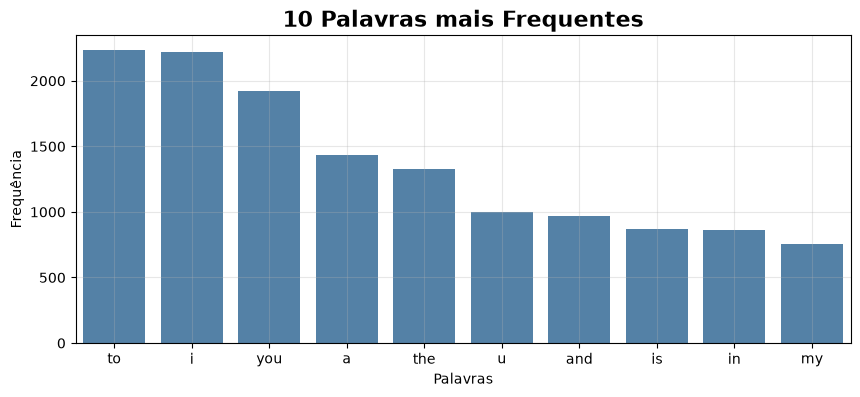

In [18]:
plt.figure(figsize=(10,4))

sns.barplot(x=df_top_words["word"], y=df_top_words["frequency"], color="steelblue")
plt.title("10 Palavras mais Frequentes", fontsize=16, fontweight="bold")
plt.xlabel("Palavras")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

### Pegando TOP 10 palavras (com StopWords)

In [19]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Unisalesiano\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
stop_words = set(stopwords.words("english"))

filtro_word = [
    word
    for word in all_words
    if word not in stop_words
]

word_freq_stop = Counter(filtro_word)

In [23]:
top_10_stop = word_freq_stop.most_common(10)

df_top_stop = pd.DataFrame(
    top_10_stop,
    columns=["word", "frequency"]
)

df_top_stop

,word,frequency
0,u,998
1,call,559
2,2,457
3,ur,385
4,get,375
5,&lt;#&gt;,276
6,go,265
7,4,255
8,.,241
9,like,236


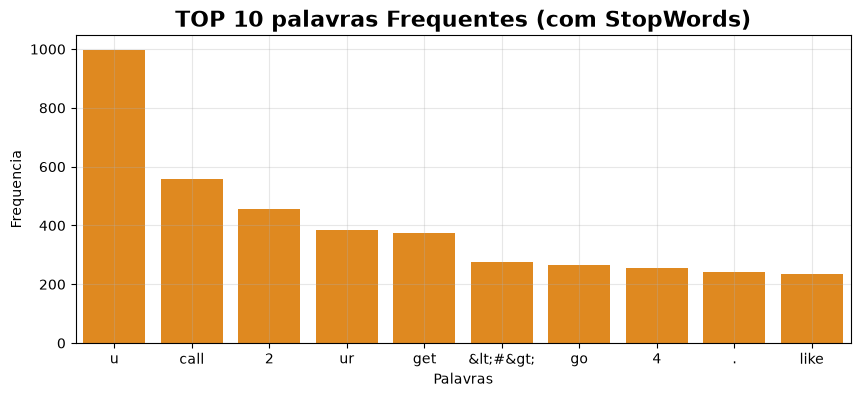

In [26]:
plt.figure(figsize=(10,4))

sns.barplot(x=df_top_stop["word"], y=df_top_stop["frequency"], color="darkorange")
plt.title("TOP 10 palavras Frequentes (com StopWords)", fontsize=16, fontweight="bold")
plt.xlabel("Palavras")
plt.ylabel("Frequencia")
plt.grid(alpha=0.3)
plt.show()

### Pegando TOP 10 Bigrams mais frequentes

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

In [30]:
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=10
)

X_bigram = vectorizer.fit_transform(dados["texto"])

bigram_freq = X_bigram.sum(axis=0).A1

df_bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "frequency": bigram_freq
}).sort_values("frequency", ascending=False)

df_bigrams

,bigram,frequency
6,lt gt,276
4,ll later,42
3,let know,40
9,sorry ll,39
2,good morning,32
1,don know,30
8,po box,28
0,decimal gt,23
5,lt decimal,23
7,new year,23


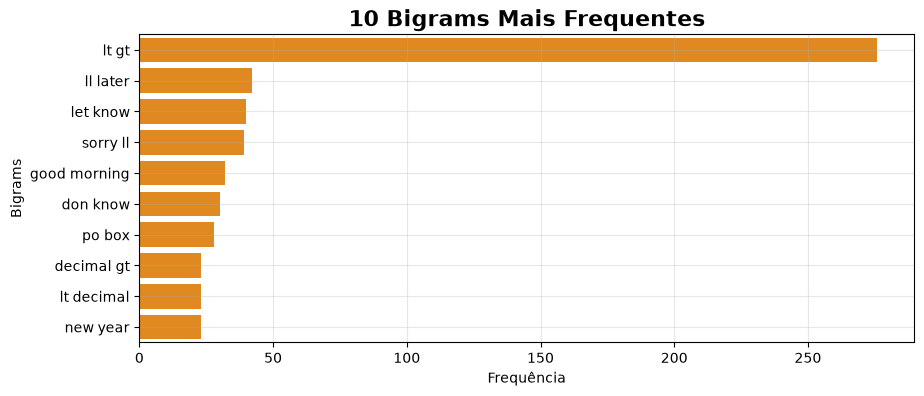

In [31]:
plt.figure(figsize=(10,4))

sns.barplot(x=df_bigrams["frequency"], y=df_bigrams["bigram"], color="darkorange")
plt.title("10 Bigrams Mais Frequentes", fontsize=16, fontweight="bold")
plt.xlabel("Frequência")
plt.ylabel("Bigrams")
plt.grid(alpha=0.3)
plt.show()